# 11 - Where is the problem? Marking abnormal sections of an ECG in red

A screening model usually answers one question: *does this ECG need a cardiologist?* My thesis tutor asked
a second one: *where in the ECG is the problem?* This notebook shows the answer we built in
[Experiment 041](../docs/experiment-041-fragment-localization.md) on one ECG at a time, with the abnormal
parts painted red.

The idea in three steps:

1. Our encoder (xECG, the one pipeline v2 uses) already cuts every 10-second ECG into **40 sections of 0.25 s**,
   each covering all 12 leads, and turns each section into a vector of 1,024 numbers.
2. We looked at the sections of 5,872 normal ECGs and learned what a normal section looks like.
3. For a new ECG, a section that is far from every normal section gets a high score. If the score is above a
   threshold, we paint that 0.25 s red.

We compare two ways of scoring a section:

- **U, unsupervised:** distance from normal sections. It never saw an abnormal label. It flags anything
  unusual.
- **G, label-guided:** how much the section pushes our existing readout (trained on cardiologist labels)
  toward "abnormal". It should flag only what the labels call abnormal.

The red threshold is set so that only 5% of normal development ECGs get any red at all. This notebook only
*shows* the method; the numbers that decide whether it works are in the
[results report](../docs/experiment-041-fragment-localization-results.md), and section 4 repeats them.

In [1]:
import os
import sys
from pathlib import Path

os.environ["CUDA_VISIBLE_DEVICES"] = ""  # one ECG at a time runs fine on the CPU; no GPU lock needed

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import json
import pickle
from io import BytesIO

import numpy as np
import pandas as pd
from IPython.display import Image, display
from matplotlib.figure import Figure
from PIL import Image as PILImage

from ecg_experiment.external_encoders import XECG_DROP_PATH, read_ptb_float64, xecg_input
from ecg_experiment.fragment_localization import (
    SECTION_SECONDS,
    SECTIONS,
    plot_sections,
    premature_windows,
    r_peaks,
    readout_contributions,
    section_mahalanobis,
    xecg_tokens,
)
from ecg_experiment.full_development import ptb_table
from ecg_experiment.xecg import load_xecg

RUN = ROOT / "outputs/experiment041_fragment_localization_v1"
saved = pickle.loads((RUN / "reference.pkl").read_bytes())
reference, head, thresholds = saved["reference"], saved["head"], saved["thresholds"]
result = json.loads((RUN / "result.json").read_text())
scores = np.load(RUN / "section_scores.npz")
table = ptb_table().set_index("ecg_id")
model = load_xecg(device="cpu", backend="vanilla", drop_path_prob=XECG_DROP_PATH).eval()


def display_small(figure: Figure, dpi: int = 65) -> None:
    """Show a figure at low resolution to keep the notebook small."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=dpi)
    small = BytesIO()
    PILImage.open(buffer).convert("RGB").quantize(colors=16).save(small, format="png", optimize=True)
    display(Image(small.getvalue()))


print("red thresholds:", {name: round(thresholds[name], 2) for name in ("U", "G")})

/home/janetrivera/ecg-cardiopathy-detection/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


creating xlstm with slstm at:  [0, 1, 4, 5, 8]


red thresholds: {'U': 157.89, 'G': 7.77}


## 1. One ECG, as the cardiologist sees it

PTB-XL ECG 219 is a development ECG whose report lists a ventricular premature complex (PVC): one beat that
starts in the ventricles, too early, with a wide and strange shape. Before any model, here are its 12 leads.
Look for the beat that does not match the others.

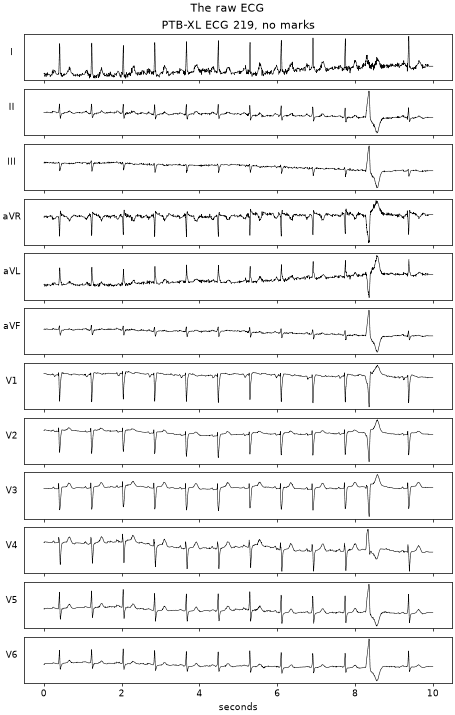

In [3]:
ECG = 219
signal = read_ptb_float64(table.at[ECG, "filename_hr"])
unmarked = {f"PTB-XL ECG {ECG}, no marks": np.zeros(SECTIONS, dtype=bool)}
display_small(plot_sections(signal, 500, unmarked, "The raw ECG"))

## 2. What the model sees: 40 scores, one per quarter second

The next cell runs the encoder on this ECG and scores its 40 sections with both maps. It also checks that the
scores match the ones the experiment saved (the experiment ran on the GPU, this notebook on the CPU, so tiny
rounding differences are expected).

In [4]:
def section_maps(signal: np.ndarray) -> dict[str, np.ndarray]:
    """U and G scores of the 40 sections of one 12 x 5000 ECG."""
    tokens = xecg_tokens(model, xecg_input(signal)[None])
    return {"U": section_mahalanobis(reference, tokens)[0], "G": readout_contributions(head, tokens)[0]}


maps = section_maps(signal)
row = int(np.flatnonzero(scores["ecg_ids"] == ECG)[0])
for name in ("U", "G"):
    difference = np.abs(maps[name] - scores[name][row]).max()
    print(f"{name}: largest difference from the saved experiment scores = {difference:.2e}")

U: largest difference from the saved experiment scores = 1.35e-03
G: largest difference from the saved experiment scores = 3.06e-05


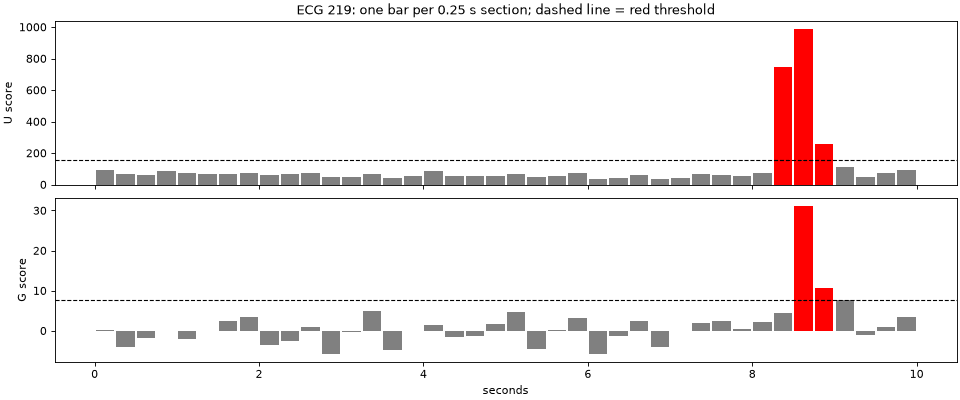

In [5]:
figure = Figure(figsize=(12, 5), layout="constrained")
axes = figure.subplots(2, 1, sharex=True)
centres = (np.arange(SECTIONS) + 0.5) * SECTION_SECONDS
for axis, name in zip(axes, ("U", "G"), strict=True):
    colours = np.where(maps[name] > thresholds[name], "red", "grey")
    axis.bar(centres, maps[name], width=SECTION_SECONDS * 0.9, color=colours)
    axis.axhline(thresholds[name], color="black", linestyle="--", linewidth=1)
    axis.set_ylabel(f"{name} score")
axes[0].set_title(f"ECG {ECG}: one bar per 0.25 s section; dashed line = red threshold")
axes[1].set_xlabel("seconds")
display_small(figure, dpi=80)

The CPU scores differ from the saved ones by about 0.001 at most, far below the U red threshold of about
158, so the red sections are the same.

Each bar is one quarter second. Grey bars are below the threshold; red bars are above it and will be painted
on the ECG. Now the same ECG with the red sections drawn on all 12 leads. To check the location without a
cardiologist, the cell also prints where an automatic rule finds an early beat (a beat that arrives sooner than
0.8 times the usual beat-to-beat interval).

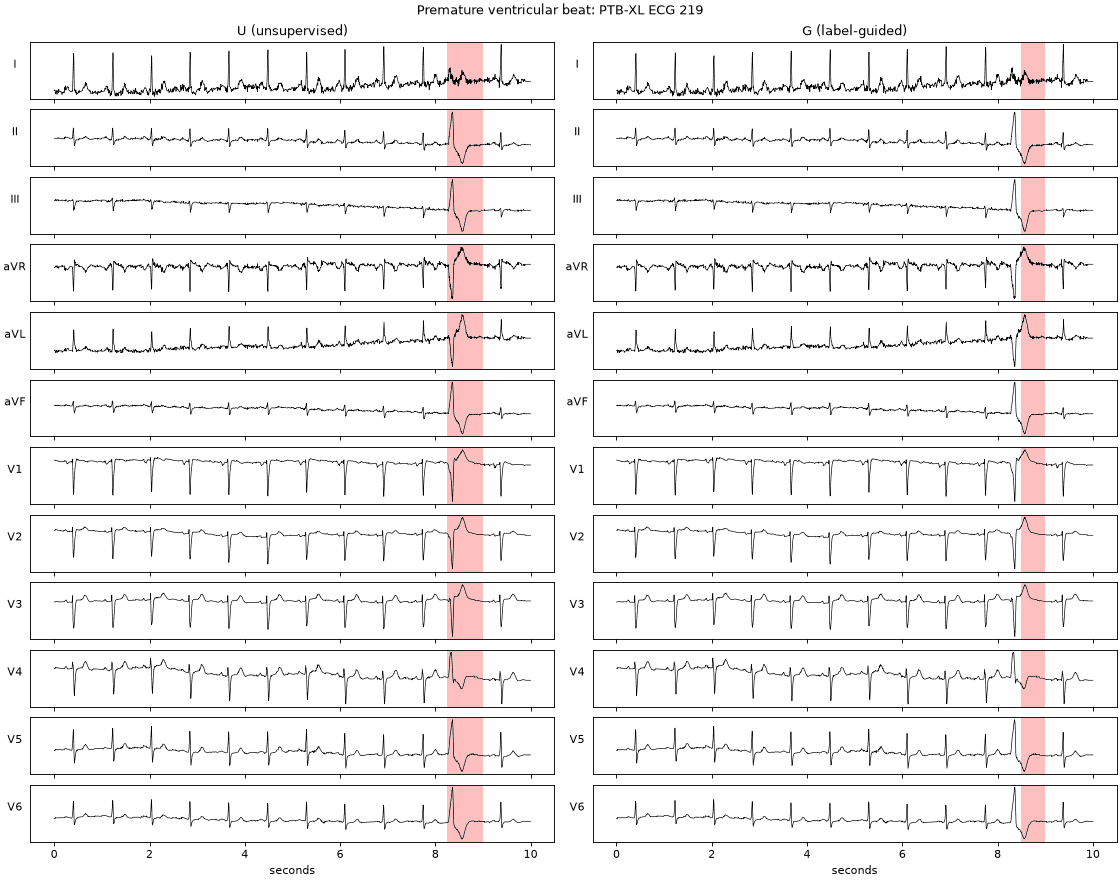

U red sections start at (s): [8.25, 8.5, 8.75]
G red sections start at (s): [8.5, 8.75]
early beats found by the rule at (s): [8.36]


In [6]:
def red_seconds(name: str, values: np.ndarray) -> list[float]:
    """Start times of the red sections of one map."""
    return [round(float(t * SECTION_SECONDS), 2) for t in np.flatnonzero(values > thresholds[name])]


def show(ecg_id: int, title: str) -> dict[str, np.ndarray]:
    """Plot one ECG with the U and G red sections and print where they are."""
    signal = read_ptb_float64(table.at[ecg_id, "filename_hr"])
    maps = section_maps(signal)
    red = {"U (unsupervised)": maps["U"] > thresholds["U"], "G (label-guided)": maps["G"] > thresholds["G"]}
    display_small(plot_sections(signal, 500, red, f"{title}: PTB-XL ECG {ecg_id}"), dpi=80)
    early = [round(float(low) + 0.10, 2) for low, _ in premature_windows(r_peaks(signal, 500), 500)]
    print("U red sections start at (s):", red_seconds("U", maps["U"]))
    print("G red sections start at (s):", red_seconds("G", maps["G"]))
    print("early beats found by the rule at (s):", early)
    return maps


_ = show(ECG, "Premature ventricular beat")

**What happened here.** The early-beat rule finds one premature beat, at about 8.3 s, and both maps paint
red sections only around it: U from 8.25 s and G from 8.5 s. The other beats look normal to both maps. This is
the case the method was built for: one odd beat among normal ones.

## 3. How each kind of ECG gets painted

Before looking at more pictures, here is what the two maps do over **all** development ECGs of each group,
read from the saved experiment scores. A group is a PTB-XL diagnostic subclass (one ECG can be in several).
"Healthy" means the 463 normal-only ECGs of the binary evaluation; "benign variant" means a normal diagnosis
with sinus bradycardia or sinus arrhythmia. This table is descriptive: it was not part of the experiment's
prespecified readings.

In [7]:
from ecg_experiment.eda.ptbxl import load_metadata, load_statements
from ecg_experiment.full_development import cohorts

GROUPS = {
    "AMI": "anterior myocardial infarction",
    "IMI": "inferior myocardial infarction",
    "ISCA": "anterior ischemia",
    "STTC": "non-specific ST/T change",
    "LVH": "left ventricular hypertrophy",
    "CLBBB": "complete left bundle branch block",
    "CRBBB": "complete right bundle branch block",
    "IRBBB": "incomplete right bundle branch block",
    "LAFB/LPFB": "left anterior or posterior fascicular block",
    "_AVB": "atrioventricular block",
    "WPW": "Wolff-Parkinson-White (pre-excitation)",
}
meta, statements = load_metadata(), load_statements()
diagnostic = statements[statements["diagnostic"] == 1]
subclass_of = diagnostic["diagnostic_subclass"].to_dict()
codes = meta["scp_codes"].apply(set)
subclasses = codes.apply(lambda found: {subclass_of[c] for c in found if c in subclass_of})
development = cohorts(ptb_table())["development"].set_index("ecg_id")
scored_ids = pd.Series(scores["ecg_ids"])
benign = [i for i in scored_ids if subclasses[i] == {"NORM"} and codes[i] <= {"NORM", "SR", "SBRAD", "SARRH"}
          and codes[i] & {"SBRAD", "SARRH"}]
members = {
    "Healthy": [i for i in scored_ids
                if development.at[i, "original"] and development.at[i, "standard"] == 0],
    "Benign variant": benign,
    "PVC (premature ventricular beat)": [i for i in scored_ids if "PVC" in codes[i]],
    **{f"{name} ({text})": [i for i in scored_ids if name in subclasses[i]] for name, text in GROUPS.items()},
}
position = pd.Series(np.arange(len(scored_ids)), index=scored_ids)
summary = {}
for group, ids in members.items():
    where = position.loc[ids].to_numpy()
    red_u = scores["U"][where] > thresholds["U"]
    red_g = scores["G"][where] > thresholds["G"]
    summary[group] = {"ECGs": len(ids),
                      "any red, U": red_u.any(axis=1).mean(), "any red, G": red_g.any(axis=1).mean(),
                      "red sections, U": red_u.sum(axis=1).mean(),
                      "red sections, G": red_g.sum(axis=1).mean()}
display(pd.DataFrame(summary).T.round(2).astype({"ECGs": int}))

,ECGs,"any red, U","any red, G","red sections, U","red sections, G"
Healthy,463,0.05,0.05,0.08,0.08
Benign variant,52,0.27,0.27,0.46,0.44
PVC (premature ventricular beat),84,1.00,1.00,6.55,17.86
AMI (anterior myocardial infarction),229,0.28,0.93,0.83,24.02
IMI (inferior myocardial infarction),227,0.28,0.81,1.11,19.26
ISCA (anterior ischemia),66,0.27,0.95,1.03,24.86
STTC (non-specific ST/T change),152,0.24,0.66,1.06,7.91
LVH (left ventricular hypertrophy),136,0.25,0.76,0.91,17.15
CLBBB (complete left bundle branch block),40,0.22,1.00,0.80,27.45
CRBBB (complete right bundle branch block),37,0.14,1.00,0.32,32.16


How to read it: "any red" is the share of ECGs with at least one red section, and "red sections" is the
average number of red sections out of 40. A good *location* map paints few sections, but on the right beat; a
good *screening* map paints at least something on almost every abnormal ECG and almost nothing on healthy
ones.

In [8]:
def show(ecg_id: int, title: str) -> None:
    """Plot one ECG with the U and G red sections and print where they are."""
    signal = read_ptb_float64(table.at[ecg_id, "filename_hr"])
    maps = section_maps(signal)
    red = {"U (unsupervised)": maps["U"] > thresholds["U"], "G (label-guided)": maps["G"] > thresholds["G"]}
    display_small(plot_sections(signal, 500, red, f"{title}: PTB-XL ECG {ecg_id}"))
    early = [round(float(low) + 0.10, 2) for low, _ in premature_windows(r_peaks(signal, 500), 500)]
    print(f"ECG {ecg_id} | U red at (s): {red_seconds('U', maps['U'])} | G red at (s): "
          f"{red_seconds('G', maps['G'])} | early beats by the rule at (s): {early}")


def show_group(group: str, count: int) -> None:
    """Show the ``count`` lowest-numbered development ECGs of a group."""
    for ecg_id in sorted(members[group])[:count]:
        show(ecg_id, group)

## 4. Healthy hearts

Four normal ECGs, then two benign variants. Ideally nothing is painted red. The threshold allows red on 5% of
normal ECGs, so an occasional red section on a healthy ECG is expected.

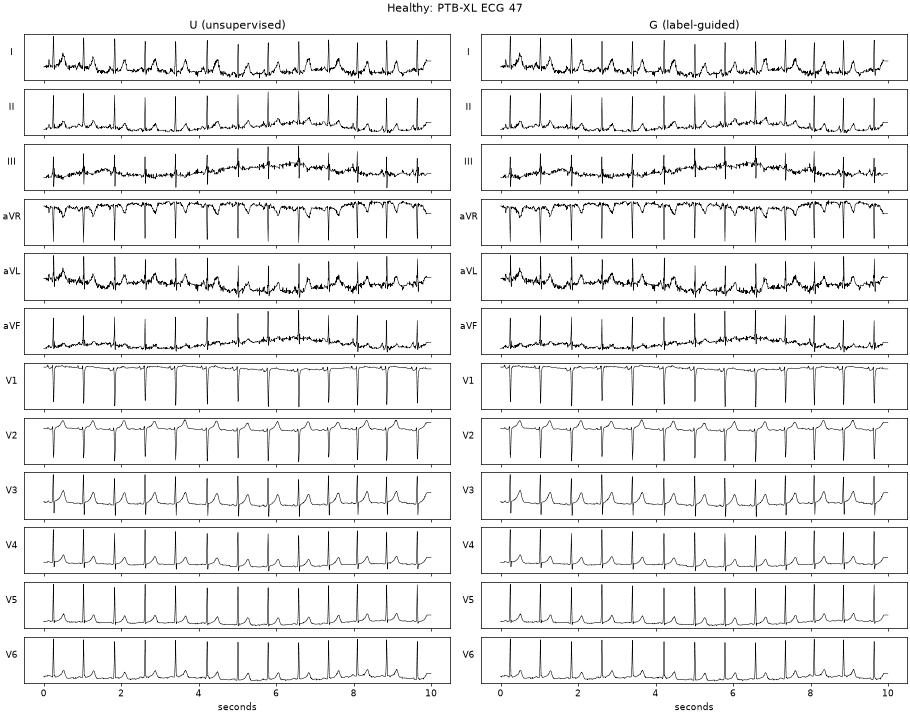

ECG 47 | U red at (s): [] | G red at (s): [] | early beats by the rule at (s): []


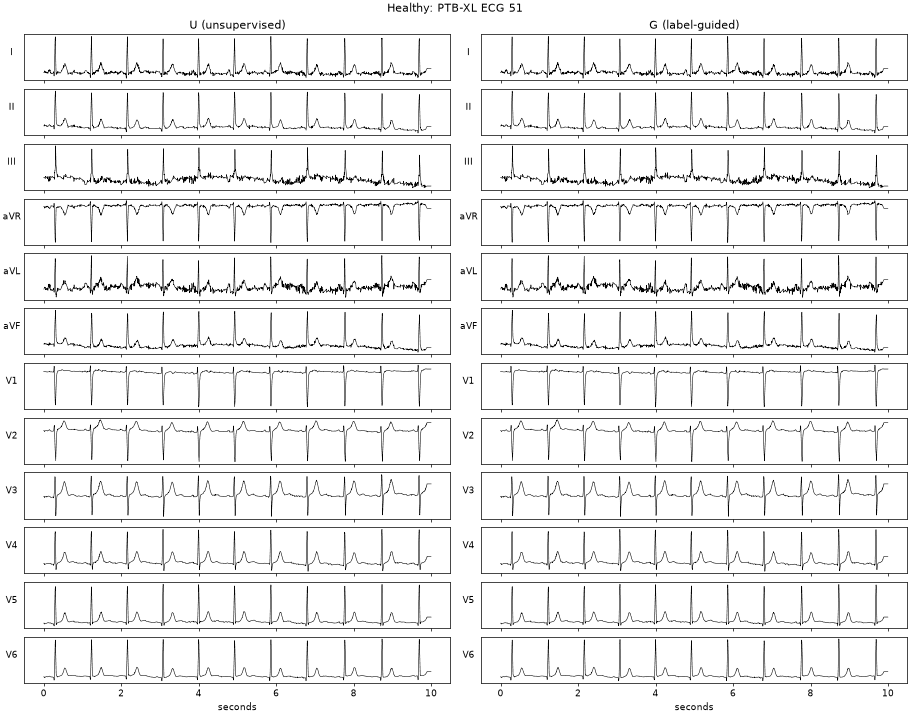

ECG 51 | U red at (s): [] | G red at (s): [] | early beats by the rule at (s): []


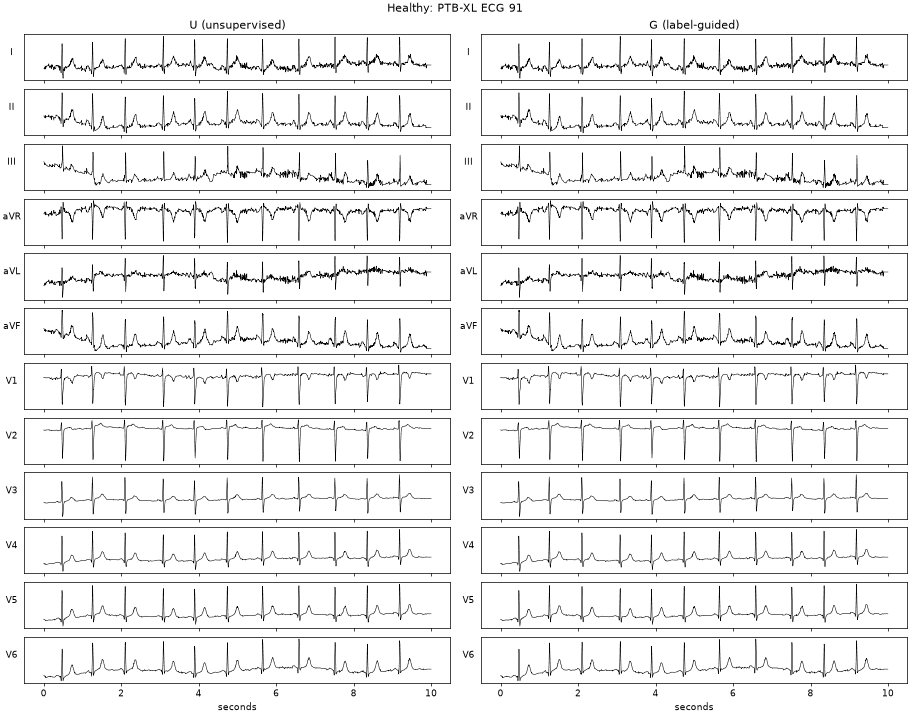

ECG 91 | U red at (s): [] | G red at (s): [] | early beats by the rule at (s): []


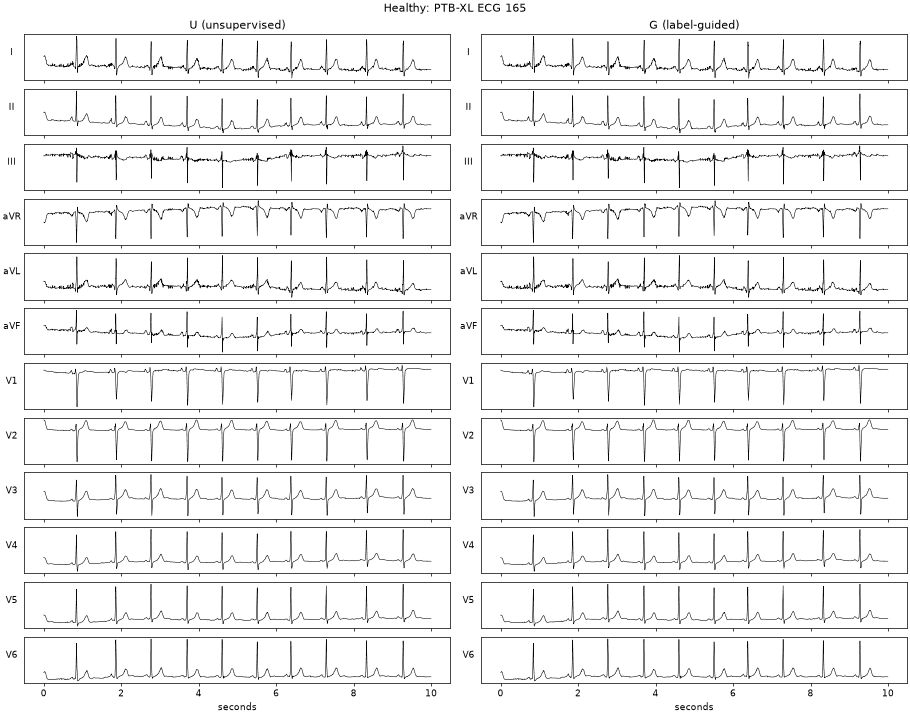

ECG 165 | U red at (s): [] | G red at (s): [] | early beats by the rule at (s): []


In [9]:
show_group("Healthy", 4)

None of the four healthy ECGs gets any red, in either map. Over all 463 healthy ECGs in the table above, 5% get some red (that is how the threshold was set), with 0.08 red sections on average.

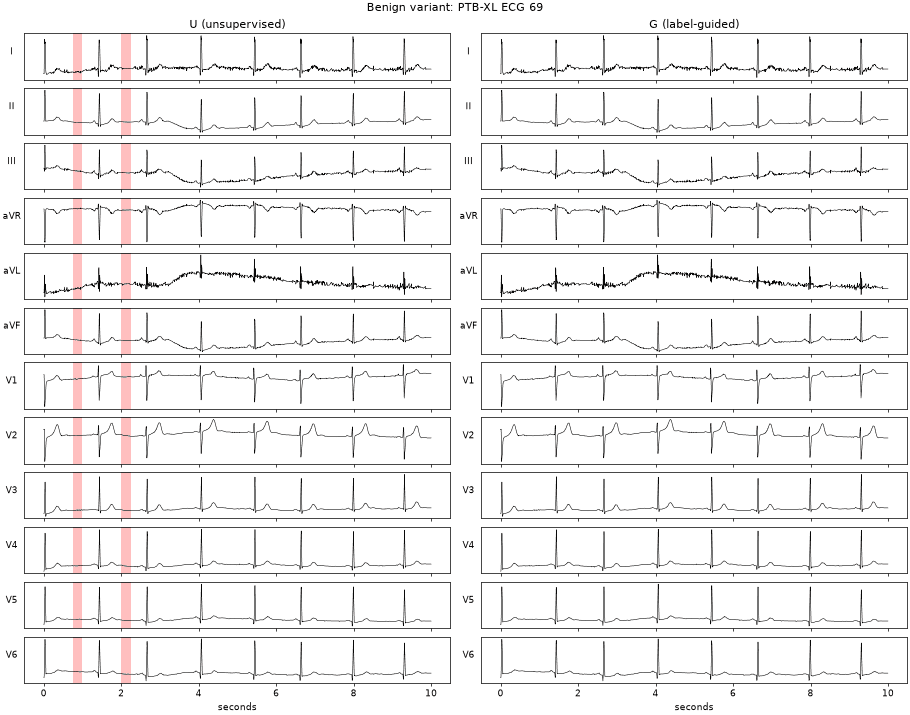

ECG 69 | U red at (s): [0.75, 2.0] | G red at (s): [] | early beats by the rule at (s): []


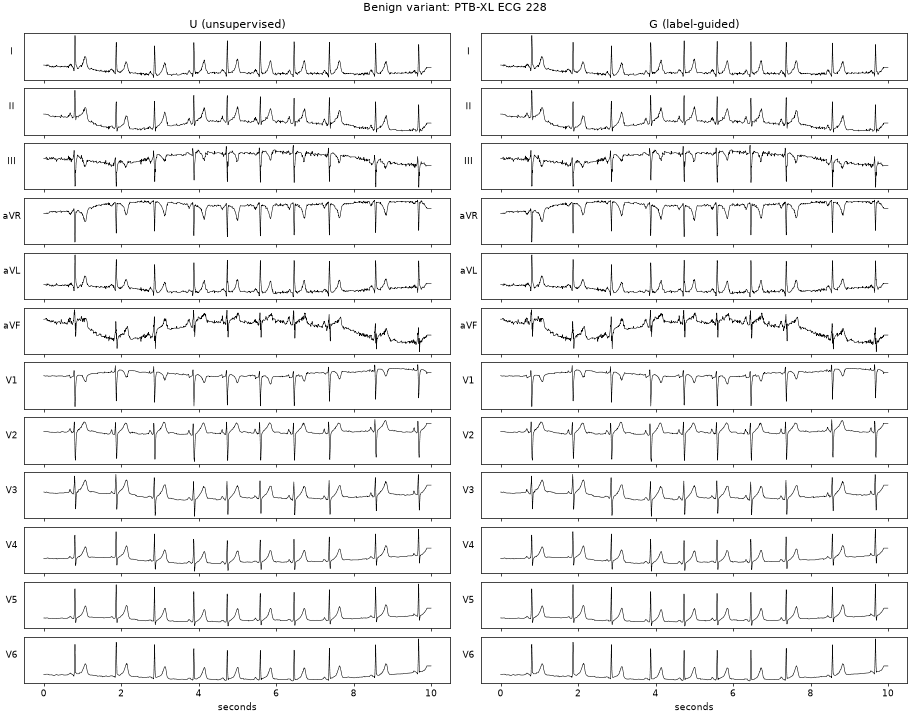

ECG 228 | U red at (s): [] | G red at (s): [] | early beats by the rule at (s): []


In [10]:
show_group("Benign variant", 2)

ECG 69 gets two thin U sections, at 0.75 s and 2.0 s, in the long pauses between beats, and nothing from G; ECG 228 gets nothing. Over all 52 benign-variant ECGs, 27% get some red with either map, about five times the healthy rate. The model still finds slow or irregular sinus rhythm a little unusual, because no benign variant was among the normal ECGs it learned from.

## 5. Different cardiopathies

Two ECGs per group, again the lowest-numbered ones in the development set. Each group starts with a one-line
description of the finding.

**Premature ventricular beat (PVC).** An early beat that starts in the ventricles, wide and oddly shaped, among normal beats.

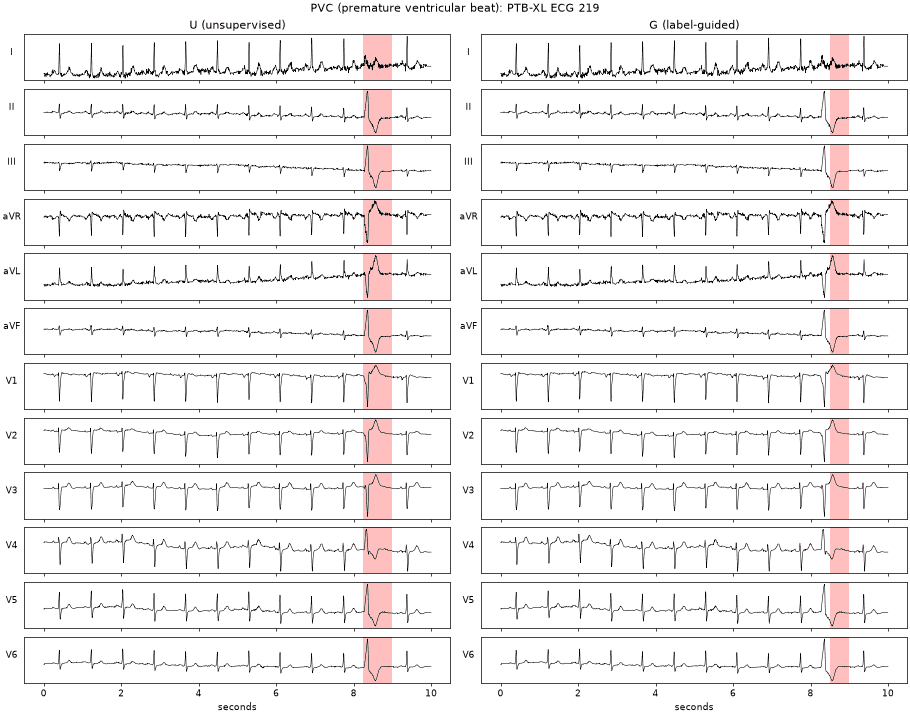

ECG 219 | U red at (s): [8.25, 8.5, 8.75] | G red at (s): [8.5, 8.75] | early beats by the rule at (s): [8.36]


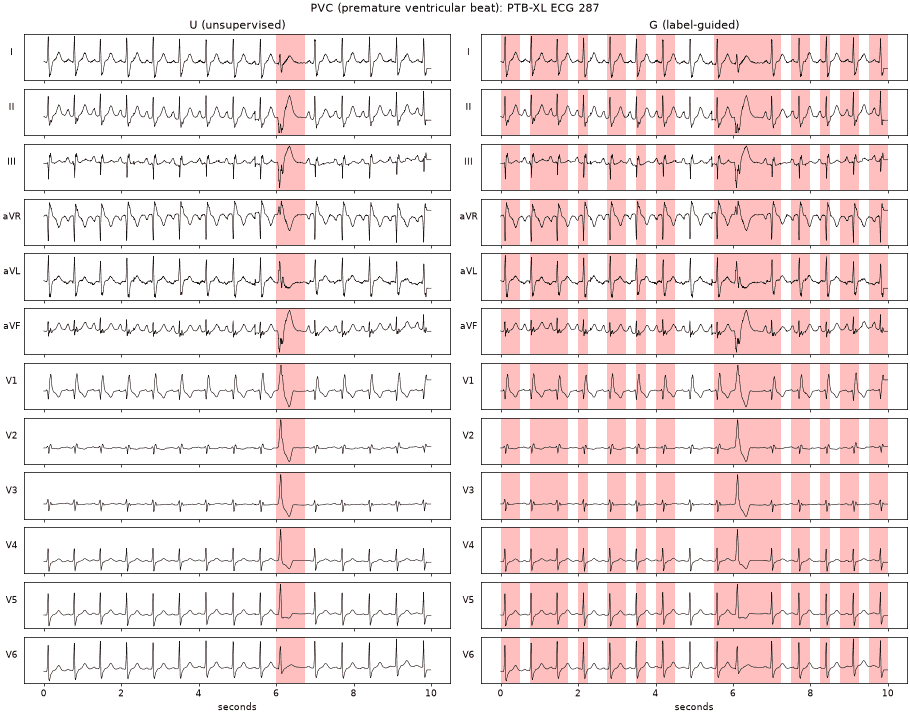

ECG 287 | U red at (s): [6.0, 6.25, 6.5] | G red at (s): [0.0, 0.25, 0.75, 1.0, 1.25, 1.5, 2.0, 2.75, 3.0, 3.5, 4.0, 4.25, 5.5, 5.75, 6.0, 6.25, 6.5, 6.75, 7.0, 7.5, 7.75, 8.25, 8.75, 9.0, 9.5, 9.75] | early beats by the rule at (s): [6.11]


In [11]:
show_group("PVC (premature ventricular beat)", 2)

In both ECGs the rule finds one early beat (at 8.36 s and 6.11 s), and U paints that beat and nothing else. G paints the same beat in ECG 219 but most of ECG 287, which also has a complete left bundle branch block (it appears again in that group). All 84 PVC ECGs get some red with both maps.

**Anterior myocardial infarction.** Scar or injury in the front wall of the left ventricle; it changes the QRS and ST-T of every beat in V1-V4.

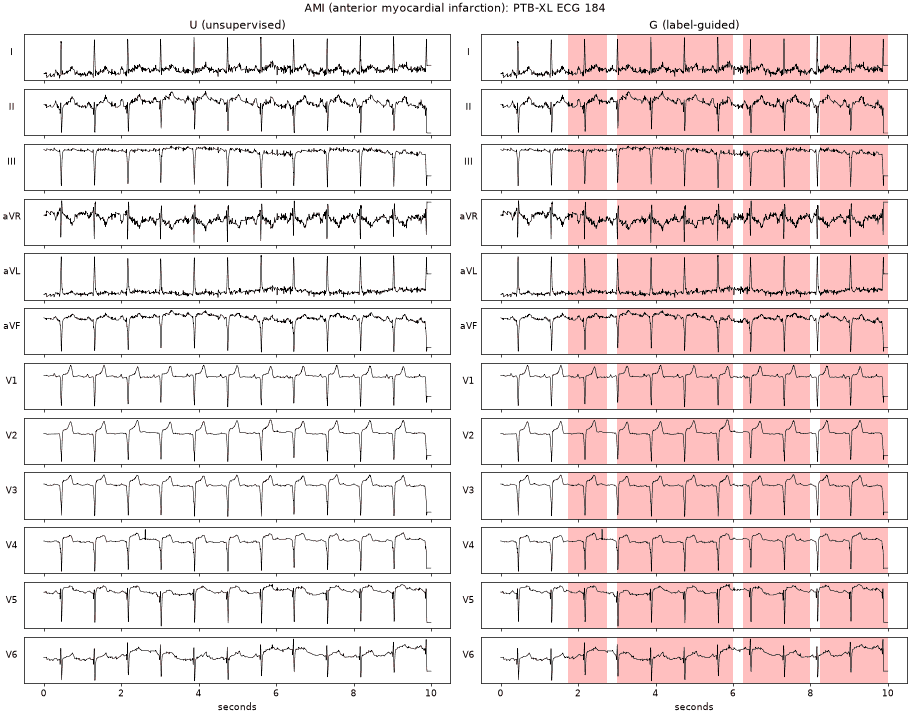

ECG 184 | U red at (s): [] | G red at (s): [1.75, 2.0, 2.25, 2.5, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.25, 5.5, 5.75, 6.25, 6.5, 6.75, 7.0, 7.25, 7.5, 7.75, 8.25, 8.5, 8.75, 9.0, 9.25, 9.5, 9.75] | early beats by the rule at (s): []


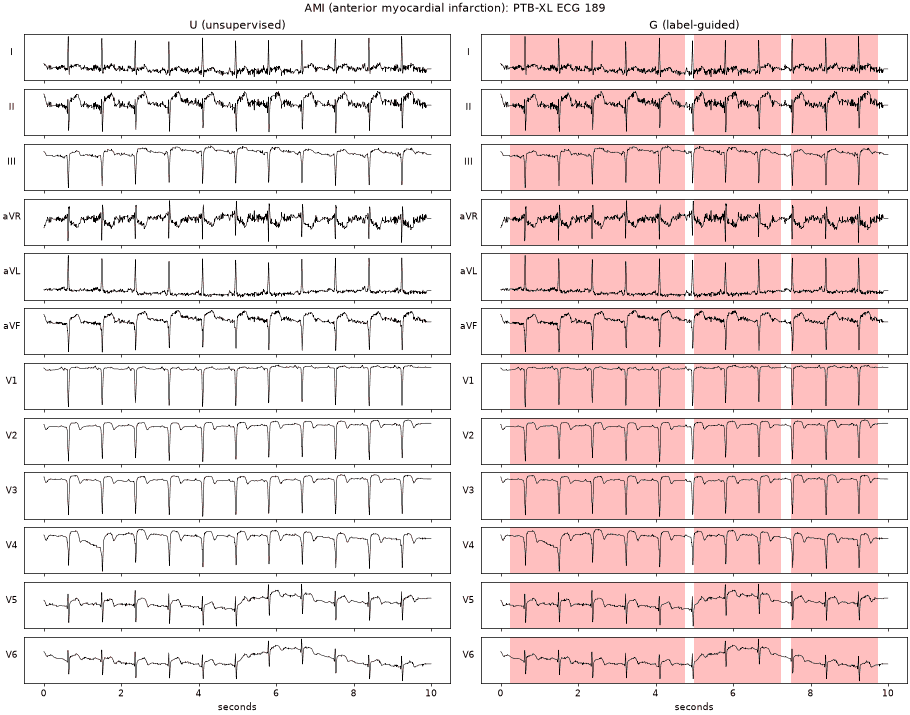

ECG 189 | U red at (s): [] | G red at (s): [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 5.0, 5.25, 5.5, 5.75, 6.0, 6.25, 6.5, 6.75, 7.0, 7.5, 7.75, 8.0, 8.25, 8.5, 8.75, 9.0, 9.25, 9.5] | early beats by the rule at (s): []


In [12]:
show_group("AMI (anterior myocardial infarction)", 2)

U paints nothing; G paints 30 and 36 of the 40 sections. An infarct changes every beat, so the label-guided map says *the whole recording* rather than *this moment*. Over all 229 anterior infarcts, U puts red on 28% and G on 93%.

**Inferior myocardial infarction.** The same in the lower wall, seen in II, III and aVF.

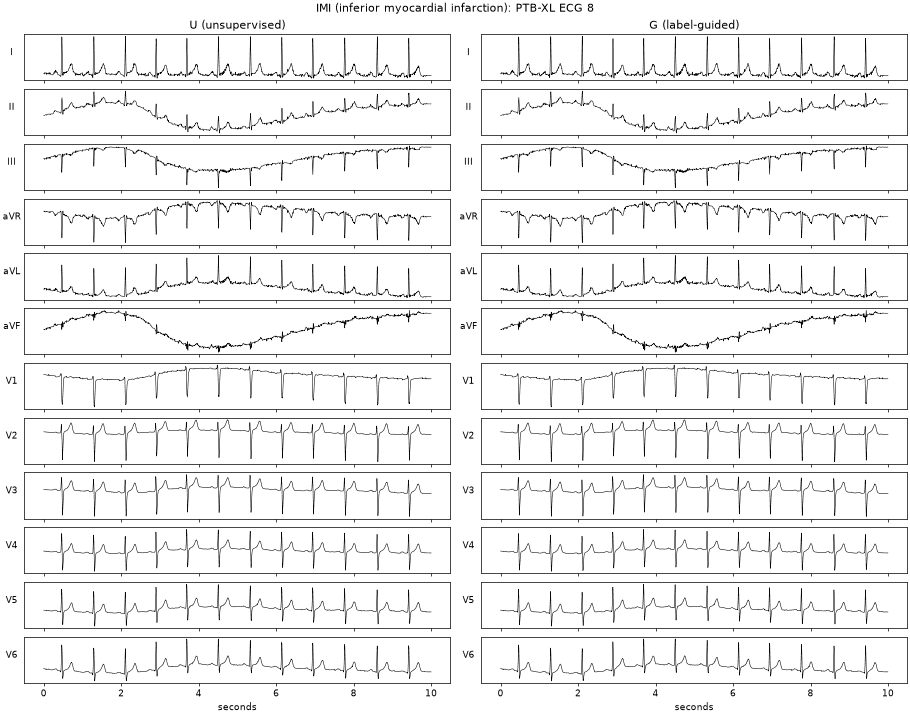

ECG 8 | U red at (s): [] | G red at (s): [] | early beats by the rule at (s): []


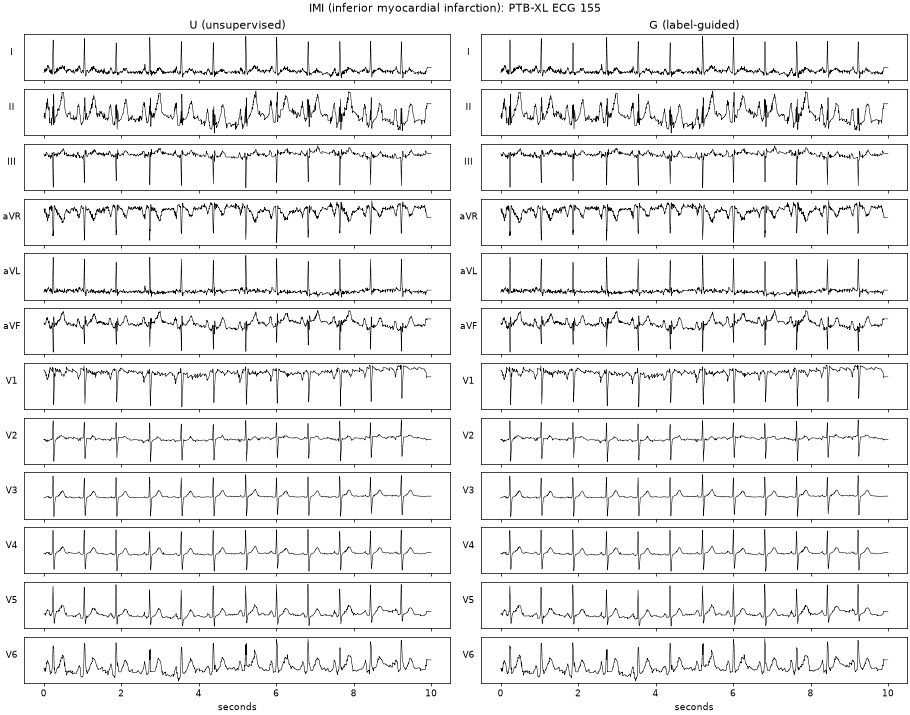

ECG 155 | U red at (s): [] | G red at (s): [] | early beats by the rule at (s): []


In [13]:
show_group("IMI (inferior myocardial infarction)", 2)

Neither map paints anything on these two. Over all 227 inferior infarcts, U puts red on 28% and G on 81%, the lowest G rate of the infarct and ischemia groups.

**Anterior ischemia.** Reduced blood flow to the front wall, seen as ST depression or T-wave inversion in every beat.

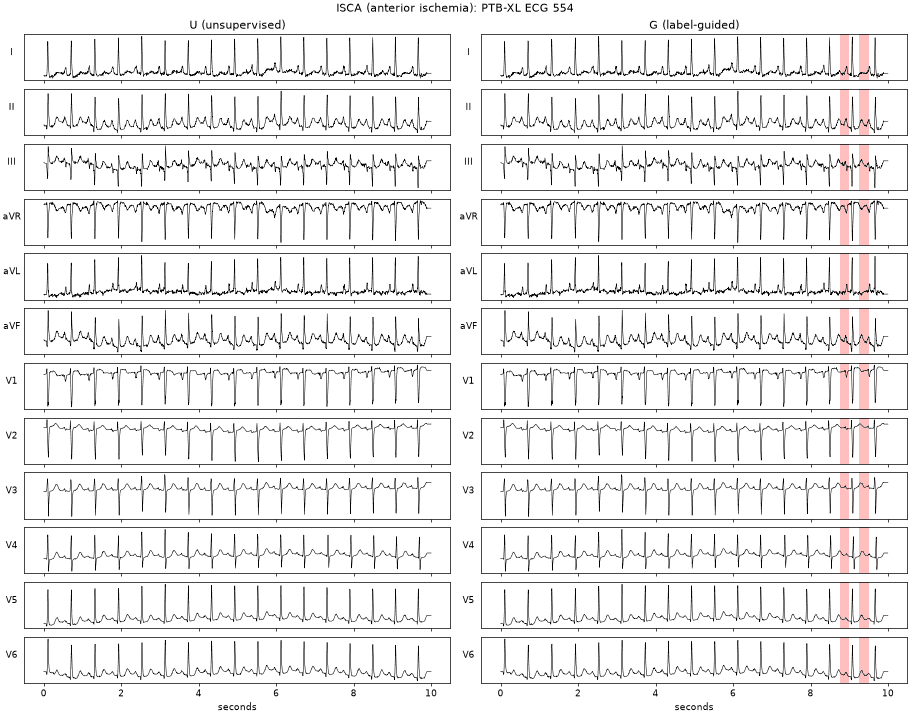

ECG 554 | U red at (s): [] | G red at (s): [8.75, 9.25] | early beats by the rule at (s): []


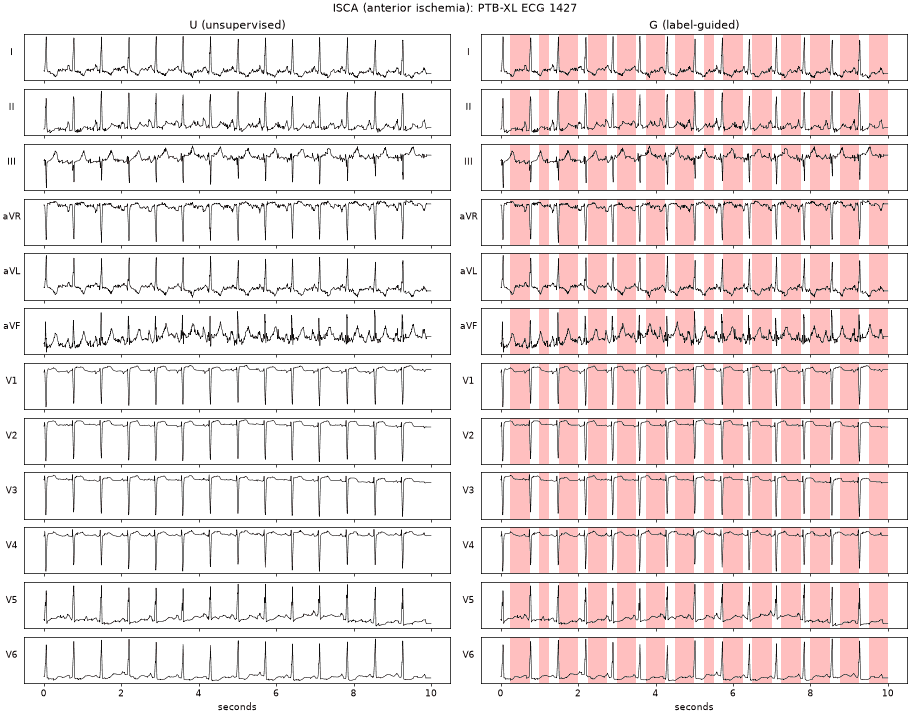

ECG 1427 | U red at (s): [] | G red at (s): [0.25, 0.5, 1.0, 1.5, 1.75, 2.25, 2.5, 3.0, 3.25, 3.75, 4.0, 4.5, 4.75, 5.25, 5.75, 6.0, 6.5, 6.75, 7.25, 7.5, 8.0, 8.25, 8.75, 9.0, 9.5, 9.75] | early beats by the rule at (s): []


In [14]:
show_group("ISCA (anterior ischemia)", 2)

U paints nothing; G paints two sections near the end of ECG 554 and 26 sections of ECG 1427. G puts red on 95% of the 66 anterior ischemia ECGs, U on 27%.

**Non-specific ST/T change.** Repolarization changes without a specific cause, in every beat.

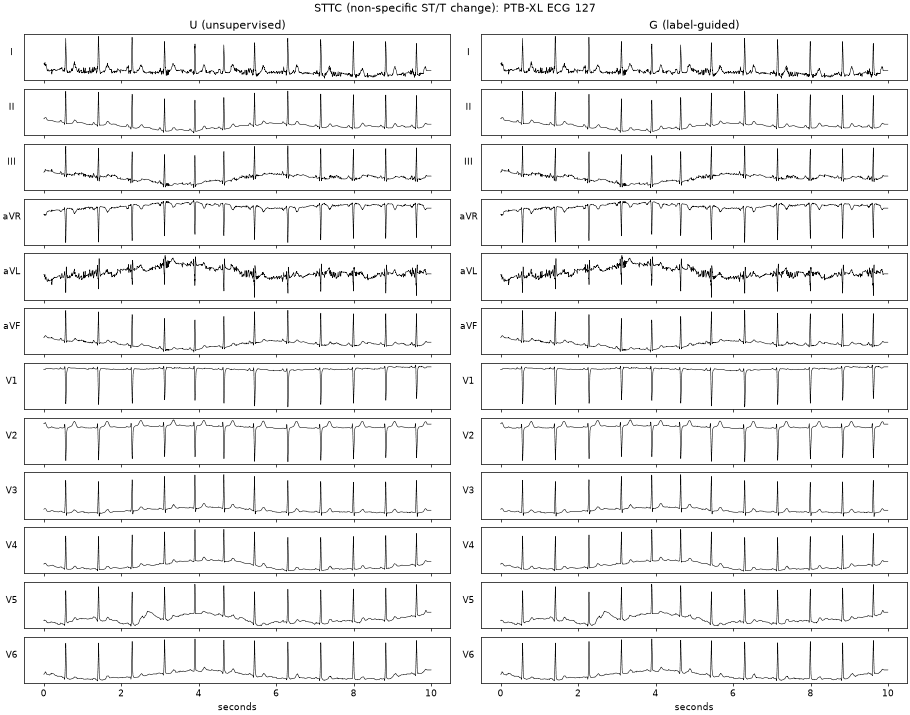

ECG 127 | U red at (s): [] | G red at (s): [] | early beats by the rule at (s): []


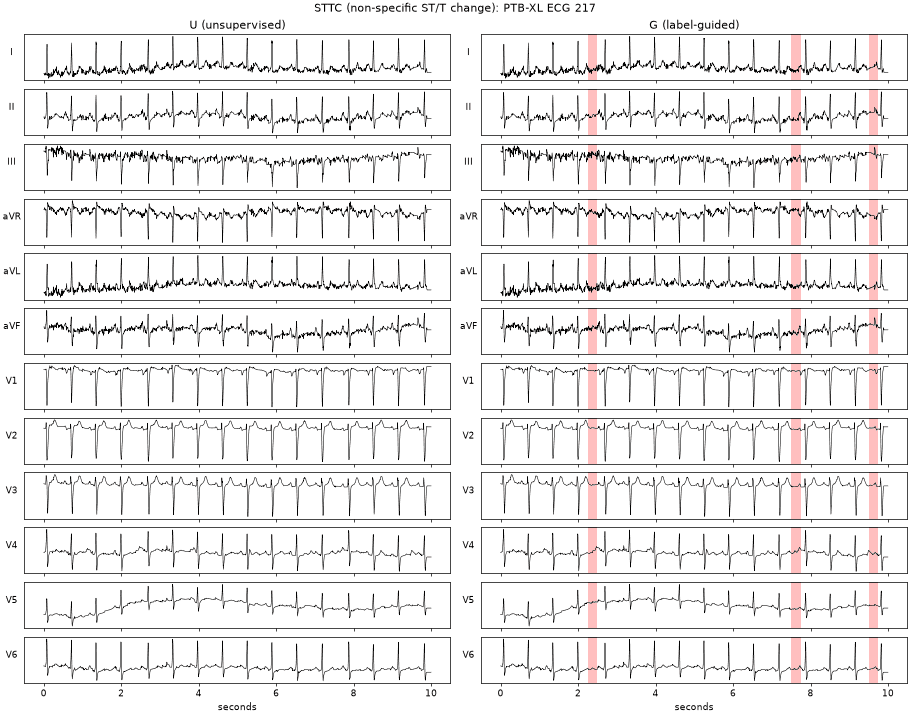

ECG 217 | U red at (s): [] | G red at (s): [2.25, 7.5, 9.5] | early beats by the rule at (s): []


In [15]:
show_group("STTC (non-specific ST/T change)", 2)

ECG 127 gets nothing; ECG 217 gets three scattered G sections. These changes are subtle: G puts red on 66% of the 152 ECGs and U on 24%.

**Left ventricular hypertrophy.** A thick left ventricle: tall QRS voltages, often with ST-T strain, in every beat.

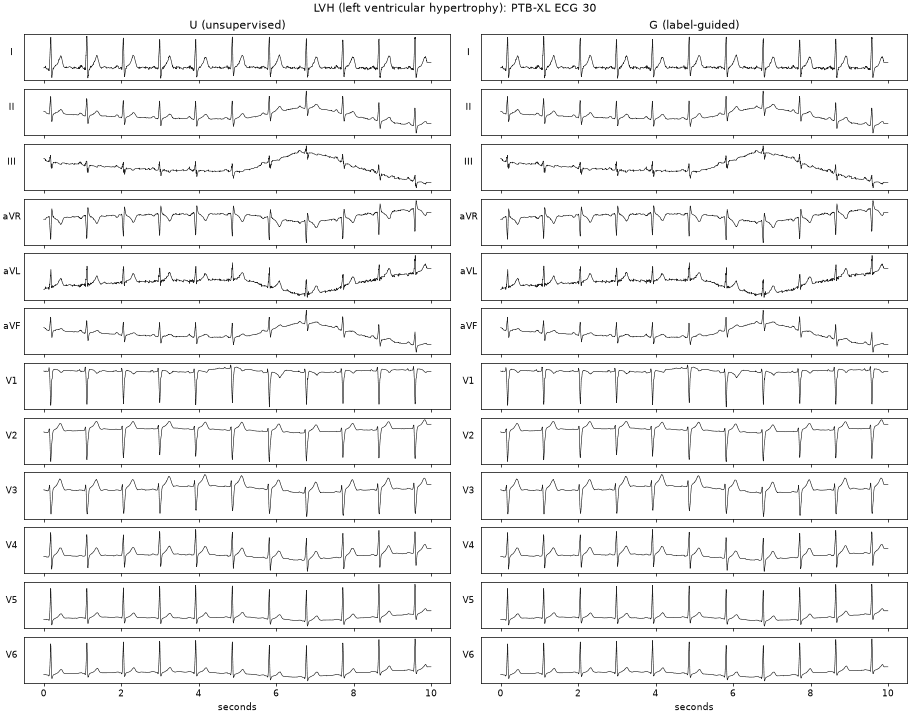

ECG 30 | U red at (s): [] | G red at (s): [] | early beats by the rule at (s): []


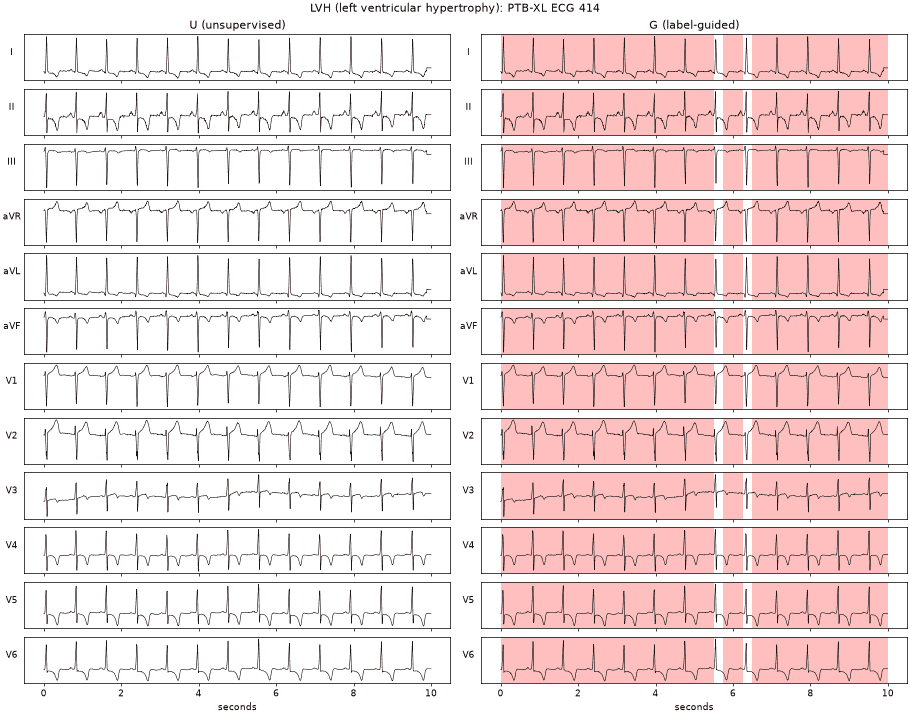

ECG 414 | U red at (s): [] | G red at (s): [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.25, 5.75, 6.0, 6.5, 6.75, 7.0, 7.25, 7.5, 7.75, 8.0, 8.25, 8.5, 8.75, 9.0, 9.25, 9.5, 9.75] | early beats by the rule at (s): []


In [16]:
show_group("LVH (left ventricular hypertrophy)", 2)

ECG 30 gets nothing; ECG 414 gets 38 of 40 G sections and no U section. G puts red on 76% of the 136 hypertrophy ECGs, U on 25%.

**Complete left bundle branch block.** The left ventricle activates late, so every QRS is wide.

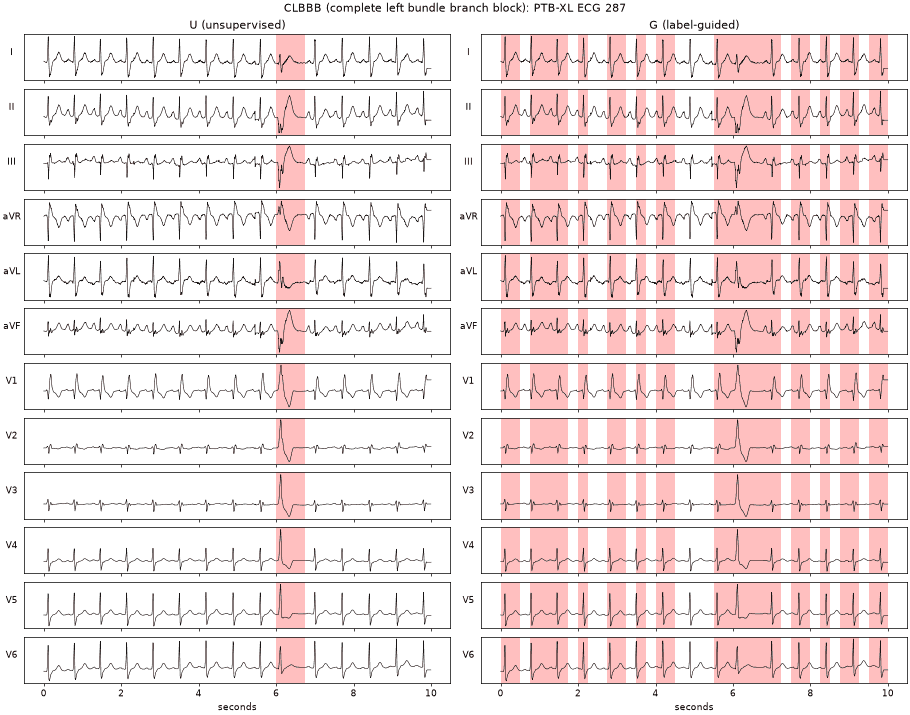

ECG 287 | U red at (s): [6.0, 6.25, 6.5] | G red at (s): [0.0, 0.25, 0.75, 1.0, 1.25, 1.5, 2.0, 2.75, 3.0, 3.5, 4.0, 4.25, 5.5, 5.75, 6.0, 6.25, 6.5, 6.75, 7.0, 7.5, 7.75, 8.25, 8.75, 9.0, 9.5, 9.75] | early beats by the rule at (s): [6.11]


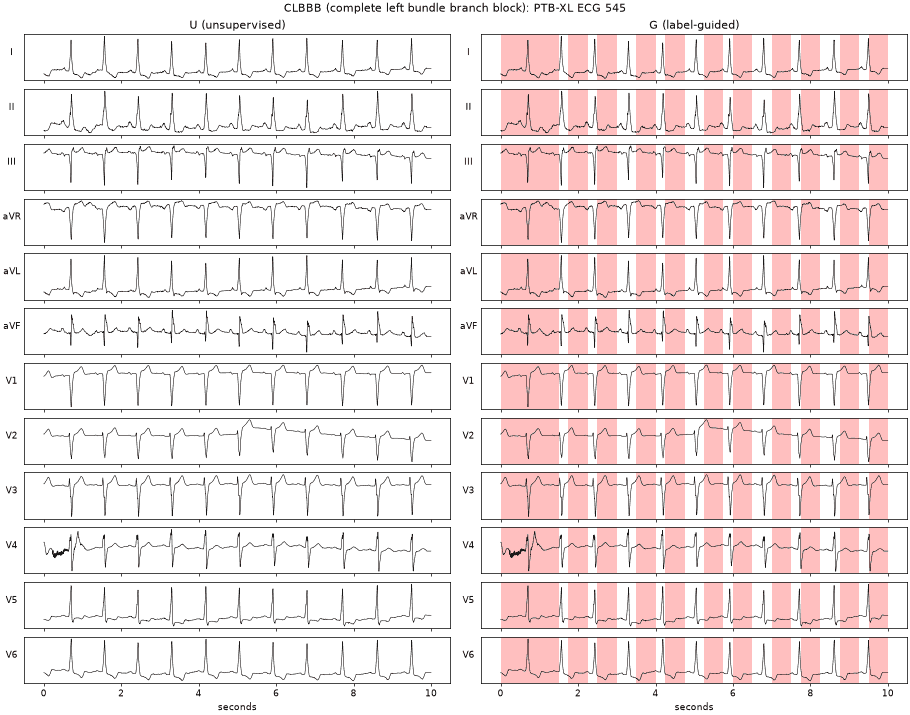

ECG 545 | U red at (s): [] | G red at (s): [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.75, 2.0, 2.5, 2.75, 3.5, 3.75, 4.25, 4.5, 5.25, 5.5, 6.0, 6.25, 7.0, 7.25, 7.75, 8.0, 8.75, 9.0, 9.5, 9.75] | early beats by the rule at (s): []


In [17]:
show_group("CLBBB (complete left bundle branch block)", 2)

ECG 287 is the one shown above: U finds its early beat, G paints most of it. ECG 545 gets no U section and 26 G sections. G puts red on all 40 complete left bundle branch block ECGs, U on 22%.

**Complete right bundle branch block.** The right ventricle activates late: wide QRS with an rSR' pattern in V1.

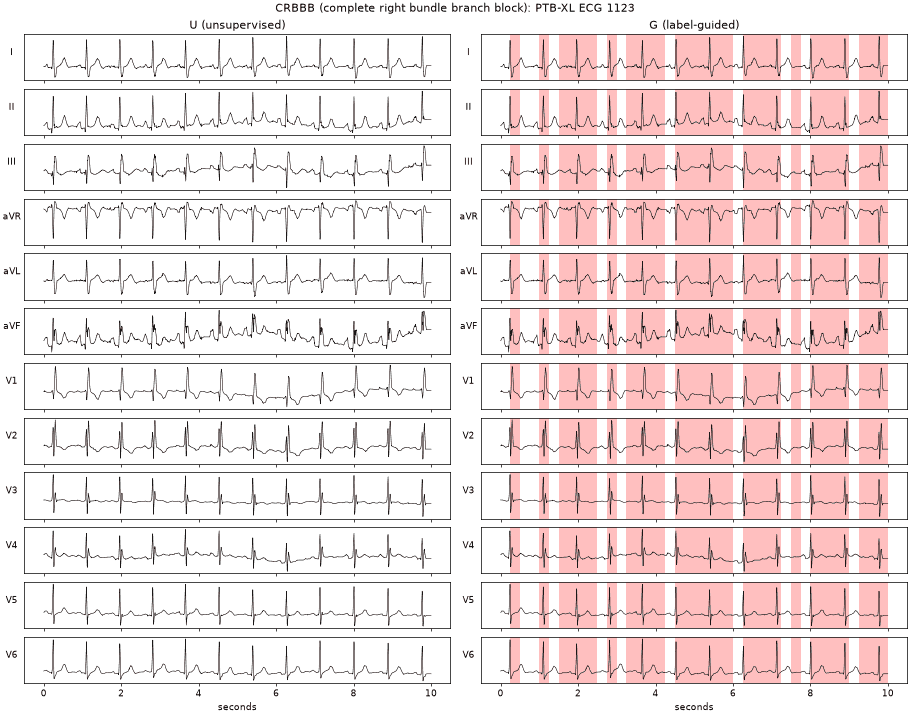

ECG 1123 | U red at (s): [] | G red at (s): [0.25, 1.0, 1.5, 1.75, 2.0, 2.25, 2.75, 3.25, 3.5, 3.75, 4.0, 4.5, 4.75, 5.0, 5.25, 5.5, 5.75, 6.25, 6.5, 6.75, 7.0, 7.5, 8.0, 8.25, 8.5, 8.75, 9.25, 9.5, 9.75] | early beats by the rule at (s): []


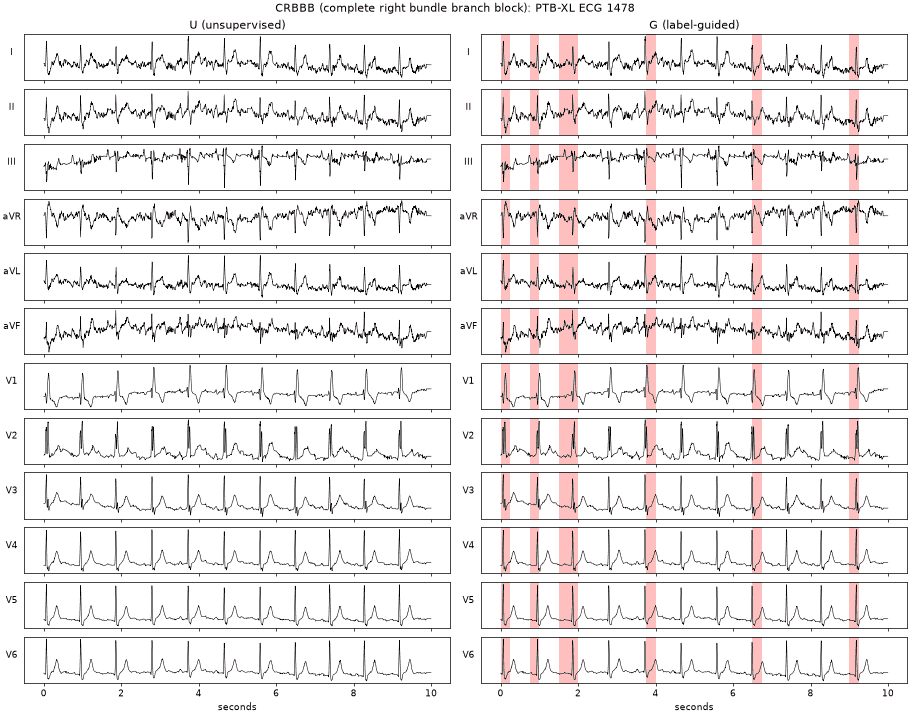

ECG 1478 | U red at (s): [] | G red at (s): [0.0, 0.75, 1.5, 1.75, 3.75, 6.5, 9.0] | early beats by the rule at (s): []


In [18]:
show_group("CRBBB (complete right bundle branch block)", 2)

No U section in either; G paints 29 and 7 sections. This group has the most G sections of any (32 of 40 on average) and the lowest U rate (14%).

**Incomplete right bundle branch block.** A milder version; common in athletes, but our binary label counts it as abnormal.

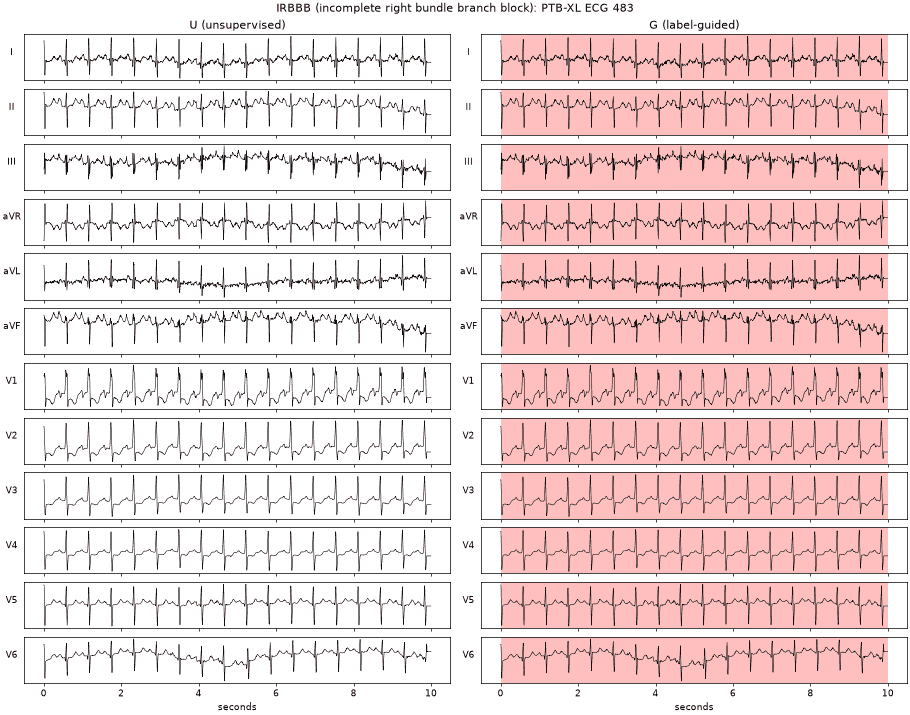

ECG 483 | U red at (s): [] | G red at (s): [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.25, 5.5, 5.75, 6.0, 6.25, 6.5, 6.75, 7.0, 7.25, 7.5, 7.75, 8.0, 8.25, 8.5, 8.75, 9.0, 9.25, 9.5, 9.75] | early beats by the rule at (s): []


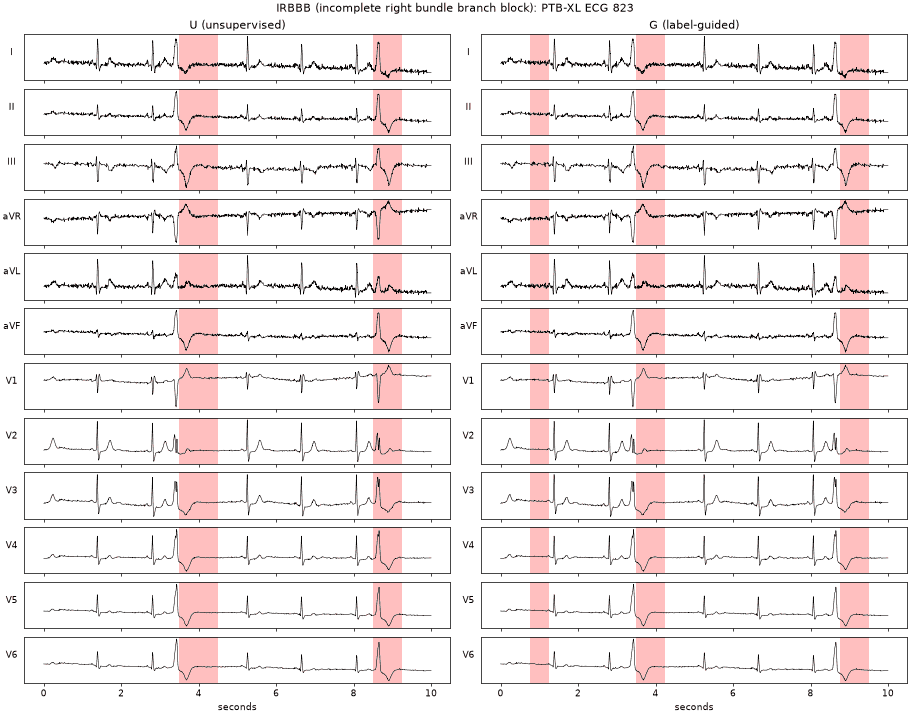

ECG 823 | U red at (s): [3.5, 3.75, 4.0, 4.25, 8.5, 8.75, 9.0] | G red at (s): [0.75, 1.0, 3.5, 3.75, 4.0, 8.75, 9.0, 9.25] | early beats by the rule at (s): [3.47, 8.69]


In [19]:
show_group("IRBBB (incomplete right bundle branch block)", 2)

ECG 483: G paints all 40 sections, U none. ECG 823 has two wide early beats (the rule finds them at 3.47 s and 8.69 s), and both maps paint exactly those beats. This group has the lowest G rate of the cardiopathies (58%).

**Fascicular block.** One branch of the left bundle is slow, which shifts the QRS axis of every beat.

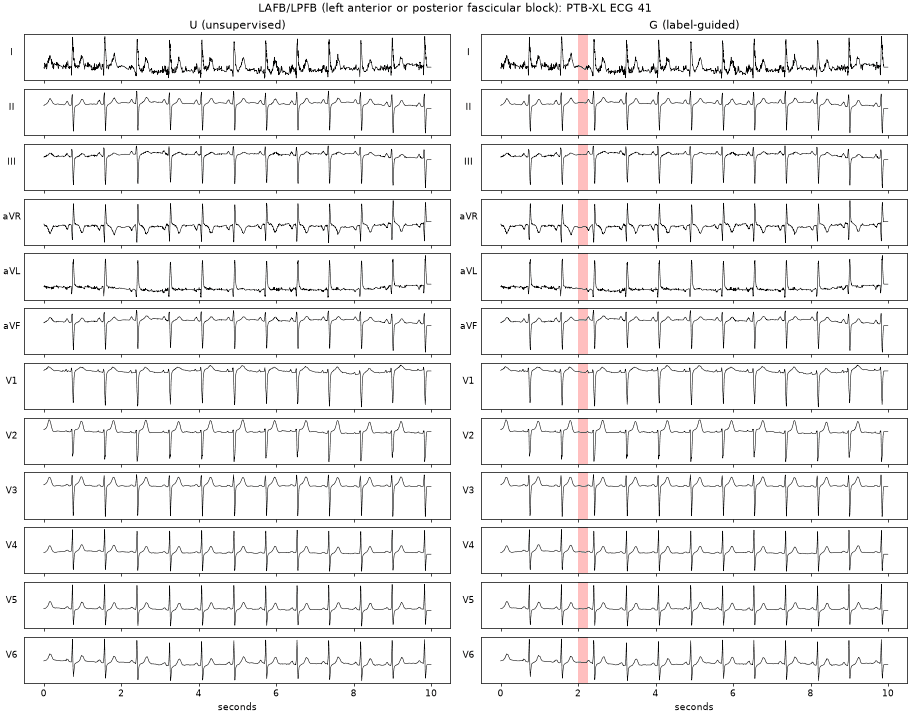

ECG 41 | U red at (s): [] | G red at (s): [2.0] | early beats by the rule at (s): []


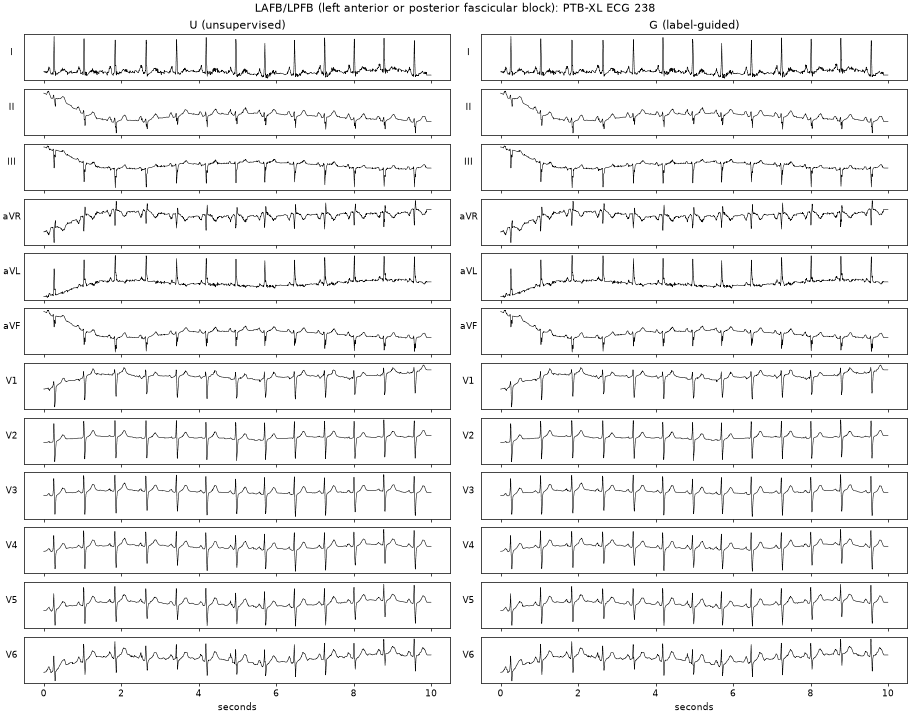

ECG 238 | U red at (s): [] | G red at (s): [] | early beats by the rule at (s): []


In [20]:
show_group("LAFB/LPFB (left anterior or posterior fascicular block)", 2)

ECG 41 gets one G section, at 2.0 s; ECG 238 gets nothing. G puts red on 83% of the 144 ECGs, U on 27%.

**Atrioventricular block.** The impulse is delayed (or sometimes lost) between atria and ventricles: a long PR interval or dropped beats.

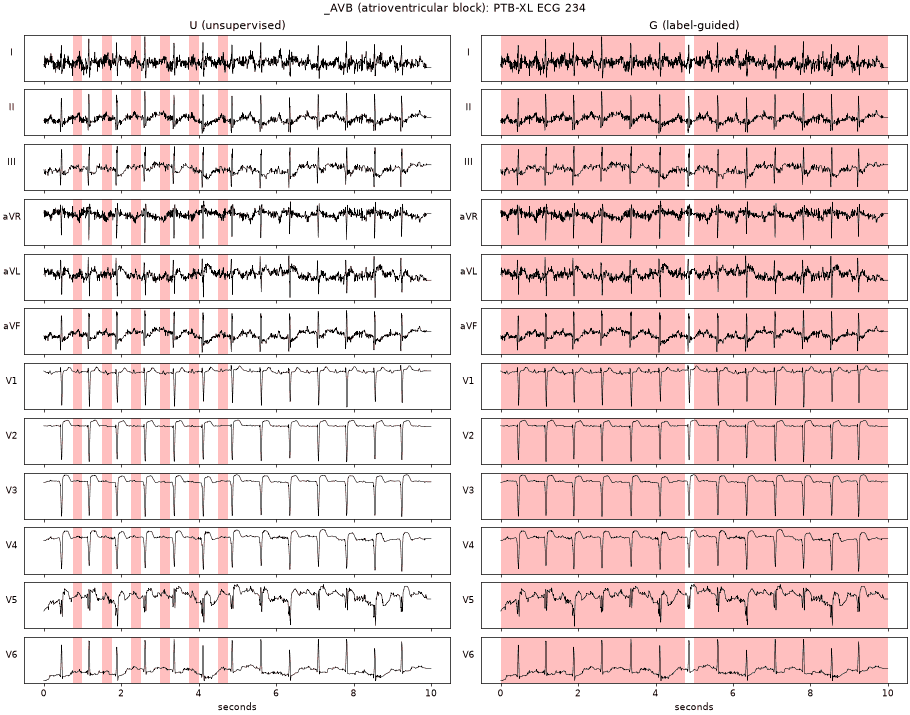

ECG 234 | U red at (s): [0.75, 1.5, 2.25, 3.0, 3.75, 4.5] | G red at (s): [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 5.0, 5.25, 5.5, 5.75, 6.0, 6.25, 6.5, 6.75, 7.0, 7.25, 7.5, 7.75, 8.0, 8.25, 8.5, 8.75, 9.0, 9.25, 9.5, 9.75] | early beats by the rule at (s): []


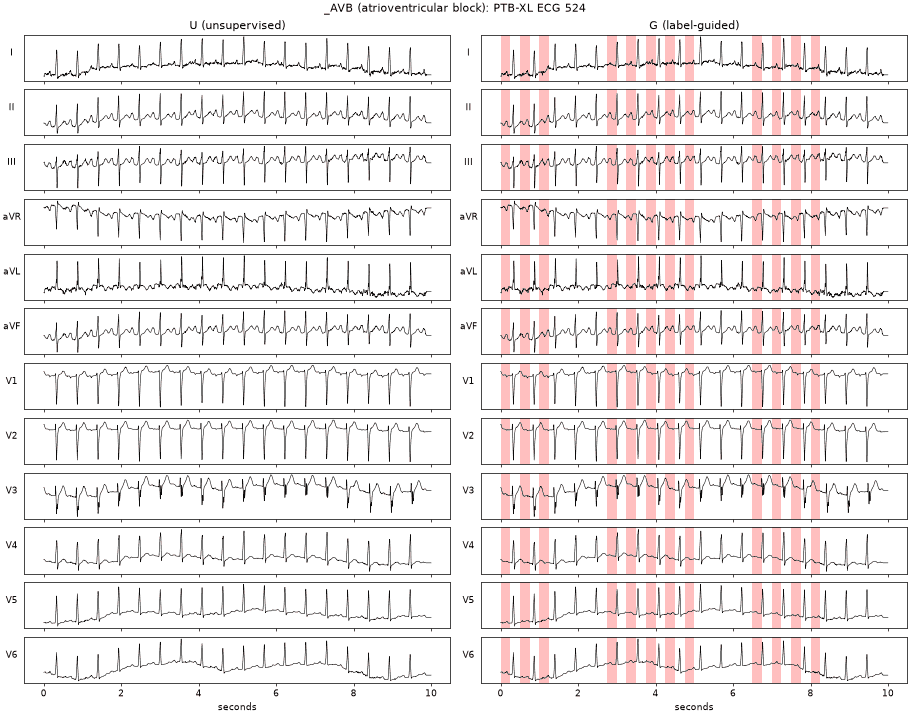

ECG 524 | U red at (s): [] | G red at (s): [0.0, 0.5, 1.0, 2.75, 3.25, 3.75, 4.25, 4.75, 6.5, 7.0, 7.5, 8.0] | early beats by the rule at (s): []


In [21]:
show_group("_AVB (atrioventricular block)", 2)

ECG 234: U paints six thin bands, evenly spaced 0.75 s apart in the first 5 s of a recording with noisy limb leads, and G paints 39 of 40 sections. ECG 524: no U section, 12 G sections. Apart from PVC, this group has the highest U rate (39%) and the most U sections (1.56 on average).

**Wolff-Parkinson-White.** An extra pathway pre-excites the ventricles: short PR and a slurred QRS start (delta wave) in every beat. Important in young people's screening.

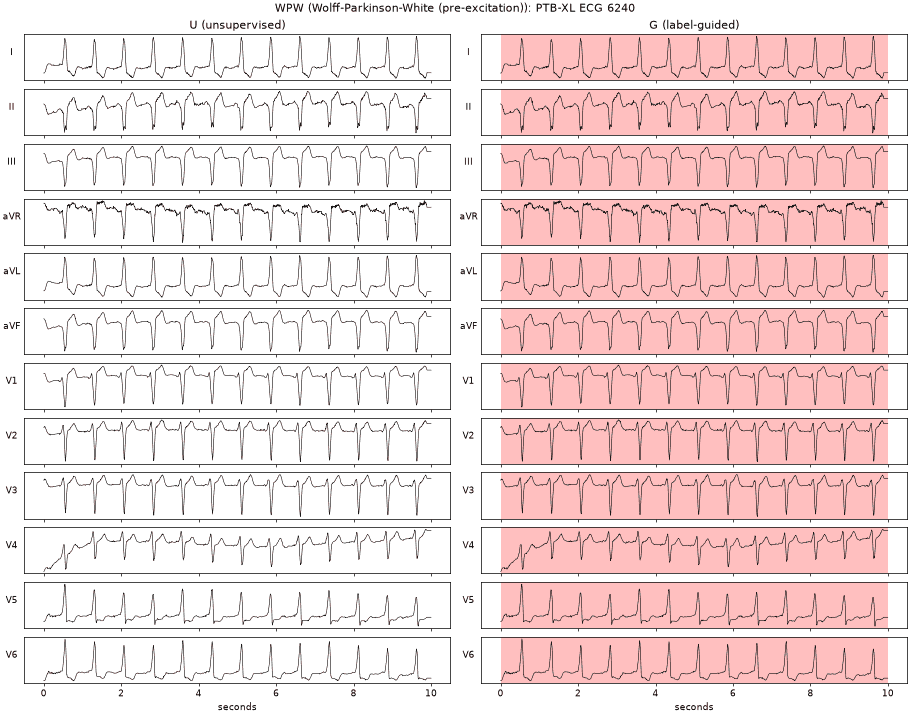

ECG 6240 | U red at (s): [] | G red at (s): [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0, 2.25, 2.5, 2.75, 3.0, 3.25, 3.5, 3.75, 4.0, 4.25, 4.5, 4.75, 5.0, 5.25, 5.5, 5.75, 6.0, 6.25, 6.5, 6.75, 7.0, 7.25, 7.5, 7.75, 8.0, 8.25, 8.5, 8.75, 9.0, 9.25, 9.5, 9.75] | early beats by the rule at (s): []


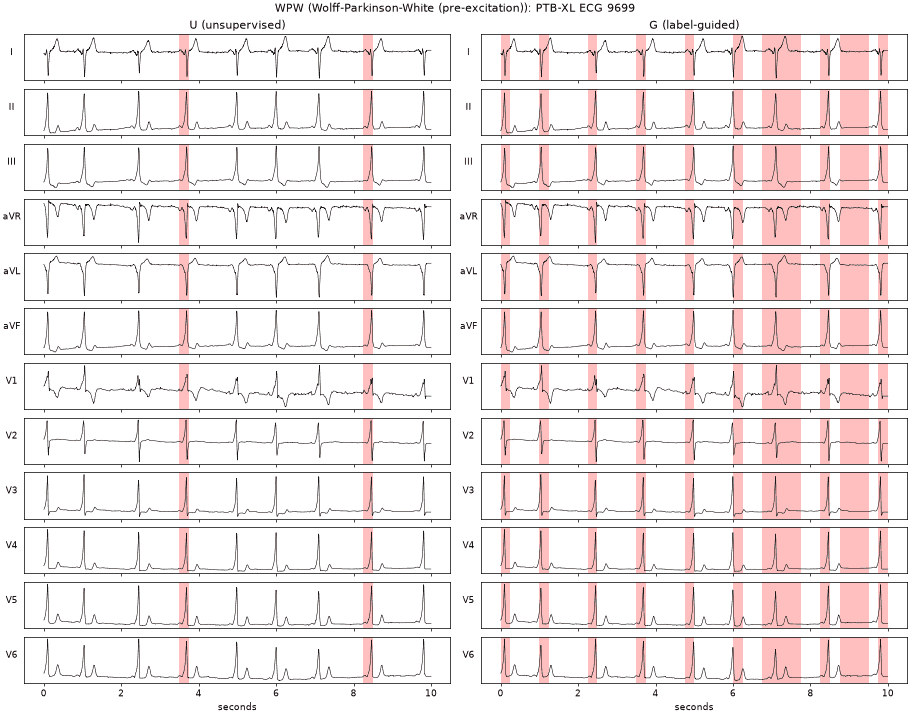

ECG 9699 | U red at (s): [3.5, 8.25] | G red at (s): [0.0, 1.0, 2.25, 3.5, 4.75, 6.0, 6.75, 7.0, 7.25, 7.5, 8.25, 8.75, 9.0, 9.25, 9.75] | early beats by the rule at (s): [1.04]


In [22]:
show_group("WPW (Wolff-Parkinson-White (pre-excitation))", 2)

ECG 6240: G paints all 40 sections, U none. ECG 9699: U paints two sections (3.5 s and 8.25 s) and G 15; the rule finds an early beat at 1.04 s, which G covers (1.0 s) and U does not. Only 6 WPW ECGs are in the development set, so the rates in the table are very uncertain.

## 6. How often does it work? The experiment's numbers

Everything below is read from the saved experiment result, not recomputed here.

**Location.** For 73 PVC ECGs where the rule found an early beat: how often is the reddest section on an early
beat, compared with picking a section at random?

,top section on an early beat,random section,"difference, 95% interval low","difference, 95% interval high"
U,0.822,0.153,0.582,0.758
G,0.767,0.153,0.513,0.713
U_kmeans,0.822,0.153,0.581,0.757


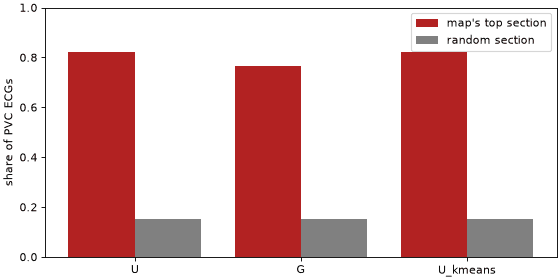

In [23]:
location = pd.DataFrame({
    name: {"top section on an early beat": result["maps"][name]["hit_rate"],
           "random section": result["maps"][name]["chance_rate"],
           "difference, 95% interval low": result["maps"][name]["hit_minus_chance"]["ci_low"],
           "difference, 95% interval high": result["maps"][name]["hit_minus_chance"]["ci_high"]}
    for name in ("U", "G", "U_kmeans")}).T.round(3)
display(location)

figure = Figure(figsize=(7, 3.5), layout="constrained")
axis = figure.subplots()
positions = np.arange(len(location))
axis.bar(positions - 0.2, location["top section on an early beat"], width=0.4, color="firebrick",
         label="map's top section")
axis.bar(positions + 0.2, location["random section"], width=0.4, color="grey", label="random section")
axis.set_xticks(positions, location.index)
axis.set_ylabel("share of PVC ECGs")
axis.set_ylim(0, 1)
axis.legend()
display_small(figure, dpi=80)

**Detection and benign variants.** Detection uses each ECG's reddest section as its score (AUROC on 1,306
development ECGs), next to the whole-ECG distance from Experiment 026. The last columns give how many ECGs in each
group get any red.

In [24]:
rows = {}
for name in ("U", "U_kmeans", "G"):
    found = result["maps"][name]
    rows[name] = {"AUROC (reddest section)": found["auroc"],
                  "any red: normal": found["any_red"]["normal"],
                  "any red: abnormal": found["any_red"]["positive"],
                  "any red: benign variant": found["any_red"]["benign"],
                  "mean red sections in abnormal ECGs": found["mean_red_sections"]["positive"]}
rows["whole ECG (Experiment 026)"] = {"AUROC (reddest section)": result["whole_ecg_026"]["auroc"]}
display(pd.DataFrame(rows).T.round(3))
print("Prespecified readings:", result["reading"])

,AUROC (reddest section),any red: normal,any red: abnormal,any red: benign variant,mean red sections in abnormal ECGs
U,0.777,0.052,0.230,0.269,0.862
U_kmeans,0.832,0.052,0.372,0.346,2.049
G,0.926,0.052,0.767,0.269,15.345
whole ECG (Experiment 026),0.923,NaN,NaN,NaN,NaN


Prespecified readings: {'part1_localizes': True, 'part1_keeps_detection': False, 'part2_improves_detection': True, 'part2_fewer_benign_marks': False, 'jepa_fallback_triggered': True}


## 7. So, does it work?

*Kind of*, and the pattern is clear:

- **Finding one strange beat: yes.** Without ever seeing an abnormal label, the unsupervised map put its
  reddest section on the premature beat in 82% of PVC ECGs, against 15% for a random section.
- **Screening with the reddest section alone: no.** Its AUROC (0.777) is far below the whole-ECG distance
  (0.923), because findings spread over every beat (infarction, hypertrophy, bundle branch block) raise all
  sections a little and none a lot, like the inferior infarct ECGs 8 and 155.
- **Labels help detection but not location.** The label-guided map detects much better (0.926) and still finds
  premature beats (77%), but on abnormal ECGs it paints about 15 of the 40 sections, so it says *the whole ECG*
  more often than *here*.
- **Benign variants are not solved.** Both maps put red on about 27% of benign-variant ECGs, against 5% of
  normal ones. Our labels never taught the model that these variants are normal.
- **Across cardiopathies** (section 3), U puts red on 14-39% of ECGs, except PVC (100%), and G on 58-100%.
  G paints between 8 and 32 of the 40 sections on average, so for these findings it marks the recording, not a
  moment. U paints a precise moment when there is one: the early beats in ECGs 219, 287 and 823.
- **The tutor's clustering** (k-means with 32 groups of normal sections) found premature beats as well as U and
  detected a little better (0.832).

A practical way to use this: let the whole-ECG score decide who is referred, and show the red sections only as
an explanation for the cardiologist. Because our main encoder could not keep detection, the plan's fallback is
next: ECG-JEPA, which cuts each lead separately and could also say *which lead* is abnormal.